# The Core Scientific Python Engine & Compilation Layer

This notebook establishes the transition from standard Python loop structures to vectorized, hardware-accelerated computation. We cover the foundational array operations, statistical and fitting utilities, tabular data manipulation, plotting paradigms, and high-speed compilation.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
from numba import jit

## 1. NumPy: Vectorized Execution & Matrix Mathematics

The fundamental flaw of pure Python lists is the boxing overhead—every single element is a wrapper object carrying type information. NumPy provides raw, contiguous C-arrays where operations run at hardware-level memory speeds.

### Task: Simulate a Relativistic Coordinate Mask

In [2]:
# Create a reproducible random seed
rng = np.random.default_rng(seed=42)

# Generate mock particle data: 1 million entries
# Momentum 'p' in MeV, azimuthal angle 'phi' in radians
n_events = 1_000_000
p_arr = rng.exponential(scale=30000.0, size=n_events)  # scale in MeV
phi_arr = rng.uniform(-np.pi, np.pi, size=n_events)

# Vectorized Operation: Calculate components simultaneously without loop structures
px = p_arr * np.cos(phi_arr)
py = p_arr * np.sin(phi_arr)

# Boolean Indexing (Masking): Select high transverse-momentum components
pt = np.sqrt(px**2 + py**2)
high_pt_mask = pt > 40000.0  # Threshold at 40 GeV

print(f"Total events tracked: {len(p_arr)}")
print(f"Events passing High-Pt filter: {np.sum(high_pt_mask)}")
print(f"Memory footprint of raw p_arr: {p_arr.nbytes / 1e6:.2f} MB")

Total events tracked: 1000000
Events passing High-Pt filter: 263750
Memory footprint of raw p_arr: 8.00 MB


## 2. SciPy: Numerical Optimizations & Statistical Fitting

While NumPy provides the array structures, SciPy delivers the algorithms. If you are writing a custom solver or manual fitting iteration routine, you are likely duplicating optimized compiled code already inside SciPy.

### Task: Model and Fit an Unbinned Invariant Mass Peak

In [3]:
from scipy.optimize import curve_fit


# 1. Define the model function (e.g., a Gaussian signal peak sitting on an exponential background)
def fit_model(x, a_sig, mean, sigma, a_bg, tau):
    signal = a_sig * np.exp(-0.5 * ((x - mean) / sigma) ** 2)
    background = a_bg * np.exp(-x / tau)
    return signal + background


# 2. Generate simulated invariant mass data
bin_centers = np.linspace(5200, 5400, 100)
true_params = [500, 5279, 15, 1000, 5000]  # True parameters resembling a B0 meson peak
sim_counts = fit_model(bin_centers, *true_params) + rng.normal(
    0, 25, size=len(bin_centers)
)

# 3. Execute bounded non-linear least-squares fit
# p0 provides initial guess constraints
initial_guess = [400, 5270, 20, 800, 4000]
popt, pcov = curve_fit(fit_model, bin_centers, sim_counts, p0=initial_guess)

# 4. Extract variances (diagonal elements of the covariance matrix)
perr = np.sqrt(np.diag(pcov))

print("--- FIT RESULTS ---")
print(f"Extracted Mass Peak Mean: {popt[1]:.3f} ± {perr[1]:.3f} MeV")
print(f"Extracted Peak Width (Sigma): {popt[2]:.3f} ± {perr[2]:.3f} MeV")

--- FIT RESULTS ---
Extracted Mass Peak Mean: 5279.091 ± 0.311 MeV
Extracted Peak Width (Sigma): 14.491 ± 0.342 MeV


---

## 3. Matplotlib: Structural Data Visualization

Visualization is the final interface before scientific publication. To maintain structural layout control, we bypass the hidden state-machine interface (`plt.plot`) and enforce the explicit object-oriented axis API.

### Task: Render the Fit Model with Uncertainty Bands

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1351/367483539.py:22: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Invariant Mass $m_{\mu\mu}$ [MeV]", fontsize=12)


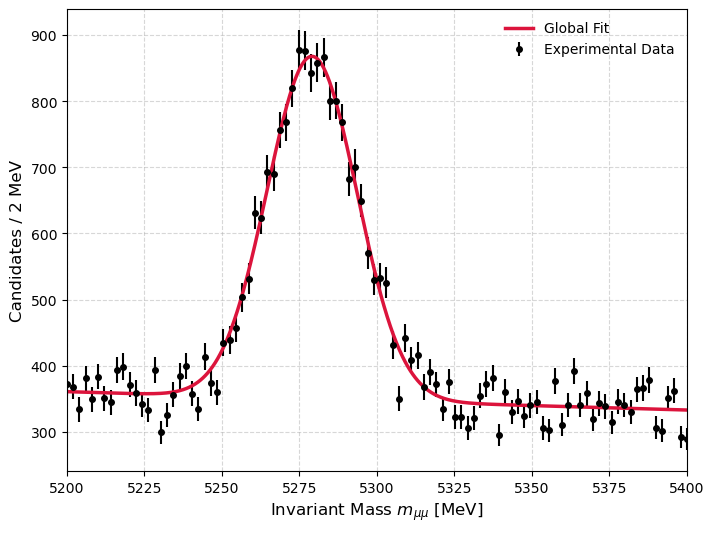

In [5]:
# Initialize figures and explicit axes
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Plot raw simulated data points with statistical error bars
ax.errorbar(
    bin_centers,
    sim_counts,
    yerr=np.sqrt(np.abs(sim_counts)),
    fmt="o",
    color="black",
    markersize=4,
    label="Experimental Data",
)

# Plot the continuous fit function
fine_x = np.linspace(5200, 5400, 1000)
ax.plot(
    fine_x, fit_model(fine_x, *popt), color="crimson", lw=2.5, label="Global Fit"
)

# Layout adjustments using the Axis Object
ax.set_xlabel("Invariant Mass $m_{\mu\mu}$ [MeV]", fontsize=12)
ax.set_ylabel("Candidates / 2 MeV", fontsize=12)
ax.set_xlim(5200, 5400)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right", frameon=False)

plt.show()

## 4. Pandas: Structured DataFrames & Analytical Pipelines

Pandas handles alignment, tabular inputs, metadata tagging, and missing values. It maps columnar fields straight into the NumPy memory layers under the hood.

### Task: Construct an Event Catalog and Calculate Aggregates

In [6]:
# Construct a structured event ledger
df = pd.DataFrame(
    {
        "EventID": rng.integers(100000, 999999, size=10_000),
        "Subdetector": rng.choice(["Barrel", "Endcap", "Forward"], size=10_000),
        "Energy": rng.exponential(scale=50.0, size=10_000),
        "IsIsolated": rng.choice([True, False], size=10_000, p=[0.7, 0.3]),
    }
)

# Filter: Retain isolated candidates within specific detector geometries
isolated_barrel = df[(df["Subdetector"] == "Barrel") & (df["IsIsolated"] == True)]

# Aggregate: Calculate mean and max energy per subdetector group
summary = (
    df.groupby("Subdetector")["Energy"].agg(["mean", "max", "count"]).round(2)
)

print("--- Dataframe Structural Tail ---")
print(isolated_barrel.tail(3))
print("\n--- Subdetector Geometry Aggregates ---")
print(summary)

--- Dataframe Structural Tail ---
      EventID Subdetector     Energy  IsIsolated
9987   162617      Barrel  54.574779        True
9989   319951      Barrel  55.624863        True
9997   361657      Barrel  27.464475        True

--- Subdetector Geometry Aggregates ---
              mean     max  count
Subdetector                      
Barrel       48.82  458.54   3391
Endcap       49.26  427.66   3299
Forward      50.83  422.45   3310


## 5. Numba: JIT Compilation to Machine Code

When vectorization isn't possible (e.g., in sequential algorithms or state-dependent tracking arrays), Python loops collapse performance. Numba intercepts the Python bytecode and compiles it down to raw LLVM machine instructions on the fly.

### Task: Benchmark a Heavy Non-Vectorizable Loop (Trimming Track Noise)

In [7]:
import time


# Python Native Implementation
def native_clean_tracks(arr, threshold):
    n = len(arr)
    output = np.empty_like(arr)
    # Simulating a loop that must inspect sequential elements (state-dependent logic)
    for i in range(n):
        if i == 0:
            output[i] = arr[i]
        else:
            output[i] = (
                arr[i] if abs(arr[i] - arr[i - 1]) < threshold else output[i - 1]
            )
    return output


# Numba JIT Compilation
# nopython=True ensures it fails-loud if it cannot optimize to pure C velocity
@jit(nopython=True)
def numba_clean_tracks(arr, threshold):
    n = len(arr)
    output = np.empty_like(arr)
    for i in range(n):
        if i == 0:
            output[i] = arr[i]
        else:
            output[i] = (
                arr[i] if abs(arr[i] - arr[i - 1]) < threshold else output[i - 1]
            )
    return output


# Prepare dummy track array
track_signals = rng.normal(100.0, 5.0, size=5_000_000)

# Profile Native Python Loop
start = time.perf_counter()
res_native = native_clean_tracks(track_signals, 2.5)
t_native = time.perf_counter() - start

# Profile Numba (First call includes compilation overhead)
start = time.perf_counter()
res_numba_first = numba_clean_tracks(track_signals, 2.5)
t_numba_compile = time.perf_counter() - start

# Profile Numba (Subsequent execution - pure machine speed)
start = time.perf_counter()
res_numba_hot = numba_clean_tracks(track_signals, 2.5)
t_numba_hot = time.perf_counter() - start

print(f"Native Python Execution Time: {t_native:.4f} seconds")
print(f"Numba Compilation + Execution: {t_numba_compile:.4f} seconds")
print(f"Numba Hot Run Execution Time:  {t_numba_hot:.4f} seconds")
print(f"Performance Speedup Factor:     {t_native / t_numba_hot:.1f}x")

Native Python Execution Time: 34.2588 seconds
Numba Compilation + Execution: 9.1995 seconds
Numba Hot Run Execution Time:  0.3983 seconds
Performance Speedup Factor:     86.0x


## 10-Minute Challenge: The Di-Muon Invariant Mass Filter
**Context**
You are analyzing collision events containing two muon candidates. To isolate clean vector meson signals (like the $J/\psi$ or $\Upsilon$), you need to compute the invariant mass of the pair and filter out low-momentum background noise.

The relativistic invariant mass $M$ for a two-particle system (assuming negligible mass compared to momentum) can be computed from their energy and momentum components:
$$M = \sqrt{(E_1 + E_2)^2 - (p_{x1} + p_{x2})^2 - (p_{y1} + p_{y2})^2 - (p_{z1} + p_{z2})^2}$$

**The Objective**
Write a purely vectorized function (no for loops) that:
 - Calculates the invariant mass $M$ for 1 million mock event pairs.
 - Applies a dual-mask requirement: both particles must have a transverse momentum ($p_T = \sqrt{p_x^2 + p_y^2}$) greater than 15 GeV, and the resulting invariant mass $M$ must be greater than 2 GeV.
 - Returns the total number of events that survive the filter.

```python
import numpy as np

# 1. Generate mock data for 1 million events
rng = np.random.default_rng(seed=1337)
n_events = 1_000_000

# Muon 1 components (in GeV)
px1 = rng.normal(0, 20, size=n_events)
py1 = rng.normal(0, 20, size=n_events)
pz1 = rng.normal(0, 50, size=n_events)
E1 = np.sqrt(px1**2 + py1**2 + pz1**2)

# Muon 2 components (in GeV)
px2 = rng.normal(0, 20, size=n_events)
py2 = rng.normal(0, 20, size=n_events)
pz2 = rng.normal(0, 50, size=n_events)
E2 = np.sqrt(px2**2 + py2**2 + pz2**2)


def filter_di_muons(px1, py1, pz1, E1, px2, py2, pz2, E2):
    # ----------------------------------------------------
    # TODO: Implement the vectorized calculation & masking
    # ----------------------------------------------------

    # Step 1: Calculate pT for both particles
    pt1 = ...
    pt2 = ...

    # Step 2: Calculate the invariant mass (M) of the system
    inv_mass = ...

    # Step 3: Create the combined boolean mask
    # Hint: Use the element-wise bitwise operator '&'
    passing_mask = ...

    # Return the number of passing events
    return np.sum(passing_mask)


# Execute and time the function
import time

start = time.perf_counter()
passing_count = filter_di_muons(px1, py1, pz1, E1, px2, py2, pz2, E2)
dt = time.perf_counter() - start

print(f"Events passing cuts: {passing_count}")
print(f"Execution time: {dt*1000:.2f} ms")

<details>
<summary><b>Click to reveal the 10-Minute Challenge: "The Di-Muon Invariant Mass Filter"</b></summary>

```python
import time
import numpy as np

# 1. Generate mock data for 1 million events
rng = np.random.default_rng(seed=1337)
n_events = 1_000_000

# Muon 1 components (in GeV)
px1 = rng.normal(0, 20, size=n_events)
py1 = rng.normal(0, 20, size=n_events)
pz1 = rng.normal(0, 50, size=n_events)
E1 = np.sqrt(px1**2 + py1**2 + pz1**2)

# Muon 2 components (in GeV)
px2 = rng.normal(0, 20, size=n_events)
py2 = rng.normal(0, 20, size=n_events)
pz2 = rng.normal(0, 50, size=n_events)
E2 = np.sqrt(px2**2 + py2**2 + pz2**2)


def filter_di_muons(px1, py1, pz1, E1, px2, py2, pz2, E2):
    # Step 1: Calculate transverse momentum (pT) for both particles
    pt1 = np.sqrt(px1**2 + py1**2)
    pt2 = np.sqrt(px2**2 + py2**2)

    # Step 2: Calculate the invariant mass (M) of the system
    inv_mass = np.sqrt(
        (E1 + E2) ** 2
        - (px1 + px2) ** 2
        - (py1 + py2) ** 2
        - (pz1 + pz2) ** 2
    )

    # Step 3: Create the combined boolean mask using bitwise operators
    passing_mask = (pt1 > 15.0) & (pt2 > 15.0) & (inv_mass > 2.0)

    # Return the total number of passing events
    return np.sum(passing_mask)


# Execute and profile the solution
start = time.perf_counter()
passing_count = filter_di_muons(px1, py1, pz1, E1, px2, py2, pz2, E2)
dt = time.perf_counter() - start

print(f"Events passing cuts: {passing_count}")
print(f"Execution time:    {dt*1000:.2f} ms")

## 10-Minute Challenge: Air Traffic Control Proximity Filter
**Context**
You are building a real-time data pipeline for an automated Air Traffic Control (ATC) system tracking 1 million pairs of commercial aircraft flights. To maintain airspace safety, you need to identify potential "near-miss" events based on telemetry data.

**The Objective**
Write a **purely vectorized** function (no for loops) that analyzes 1 million telemetry snapshots to:

- Calculate the **3D Euclidean separation distance** between Aircraft 1 and Aircraft 2:
  $$\text{Distance} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2 + (z_1 - z_2)^2}$$
- Calculate the horizontal ground speed for both aircraft ($v = \sqrt{v_x^2 + v_y^2}$).
- Filter for high-risk scenarios: Identify events where the aircraft are dangerously close (**distance < 5.0 km**), but both aircraft are traveling at high speeds (**ground speed > 400 km/h**).
- Return the total count of high-risk events.

```python
import numpy as np
import time

# 1. Generate mock flight tracking data for 200,000 events to protect your 1 GB container memory limit
rng = np.random.default_rng(seed=42)
n_events = 200_000

# Airspace dimensions: 500 km x 500 km sector
# Aircraft 1 Telemetry: Position (x,y,z in km), Velocity (vx, vy in km/h)
x1 = rng.uniform(-250, 250, size=n_events)
y1 = rng.uniform(-250, 250, size=n_events)
z1 = rng.uniform(3, 11, size=n_events)  # Cruise altitudes between 3km and 11km

vx1 = rng.normal(450, 50, size=n_events)
vy1 = rng.normal(450, 50, size=n_events)

# Spread flights out vastly across the sector 
# Aircraft are not clustered tightly by default
# Aircraft 2 Telemetry
x2 = rng.uniform(-250, 250, size=n_events)
y2 = rng.uniform(-250, 250, size=n_events)
z2 = rng.uniform(3, 11, size=n_events)

vx2 = rng.normal(450, 50, size=n_events)
vy2 = rng.normal(450, 50, size=n_events)


def find_high_risk_events(x1, y1, z1, vx1, vy1, x2, y2, z2, vx2, vy2):
    # Step 1: 3D Euclidean distance (in km)
    distance = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2)

    # Step 2: Ground speeds (in km/h)
    speed1 = np.sqrt(vx1**2 + vy1**2)
    speed2 = np.sqrt(vx2**2 + vy2**2)

    # Step 3: Tighten proximity rule to a realistic critical threshold (under 2 km)
    # Both aircraft must also be traveling at high cruise velocities (> 600 km/h)
    high_risk_mask = (distance < 2.0) & (speed1 > 600.0) & (speed2 > 600.0)

    return np.sum(high_risk_mask)


# Execute and profile
start = time.perf_counter()
risk_count = find_high_risk_events(x1, y1, z1, vx1, vy1, x2, y2, z2, vx2, vy2)
dt = time.perf_counter() - start

print(f"High-risk near-miss events detected: {risk_count}")
print(f"Pipeline execution time: {dt*1000:.2f} ms")

<details>
<summary><b>Click to reveal the 10-Minute Challenge: "Air Traffic Control Proximity Filter"</b></summary>

```python
def find_high_risk_events(x1, y1, z1, vx1, vy1, x2, y2, z2, vx2, vy2):
    # Step 1: 3D Euclidean distance
    distance = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2 + (z1 - z2) ** 2)

    # Step 2: Ground speeds
    speed1 = np.sqrt(vx1**2 + vy1**2)
    speed2 = np.sqrt(vx2**2 + vy2**2)

    # Step 3: Combined mask evaluation
    high_risk_mask = (distance < 5.0) & (speed1 > 400.0) & (speed2 > 400.0)

    return np.sum(high_risk_mask)